## Simple Linear Regression:

In [2]:
## importing Important Libraries:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
%matplotlib inline

In [3]:
# Loading the Dataset:
df = pd.read_csv('../datasets/Excel-Datasets/disease_prediction.csv')

In [4]:
df.head()

,patient_id,age,gender,glucose_mg_dl,cholesterol_mg_dl,systolic_bp,diastolic_bp,bmi,heart_rate,smoking,alcohol_consumption,physical_activity,family_history,disease
0,1,32,Male,101,235,152,79,28.5,73,No,Yes,Low,Yes,Yes
1,2,31,Male,124,191,134,77,33.9,71,No,Yes,Low,Yes,Yes
2,3,45,Male,57,141,114,71,27.2,79,Yes,Yes,Low,No,No
3,4,75,Female,69,268,120,82,21.5,61,Yes,Yes,Medium,No,Yes
4,5,53,Male,107,163,131,75,23.3,73,Yes,No,Low,Yes,Yes


In [5]:
df.describe()

,patient_id,age,glucose_mg_dl,cholesterol_mg_dl,systolic_bp,diastolic_bp,bmi,heart_rate
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,51.190000,104.163000,210.014000,123.893000,81.032000,26.093000,75.968000
std,288.819436,19.847514,25.076508,39.749111,18.701211,9.969974,4.758282,9.902982
min,1.000000,18.000000,30.000000,89.000000,67.000000,49.000000,16.000000,47.000000
25%,250.750000,33.000000,87.000000,183.000000,111.000000,74.000000,22.900000,70.000000
50%,500.500000,52.500000,105.000000,210.500000,124.000000,81.000000,26.000000,76.000000
75%,750.250000,69.000000,121.000000,235.250000,135.000000,88.000000,29.300000,83.000000
max,1000.000000,85.000000,184.000000,339.000000,195.000000,113.000000,41.500000,114.000000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   patient_id           1000 non-null   int64  
 1   age                  1000 non-null   int64  
 2   gender               1000 non-null   object 
 3   glucose_mg_dl        1000 non-null   int64  
 4   cholesterol_mg_dl    1000 non-null   int64  
 5   systolic_bp          1000 non-null   int64  
 6   diastolic_bp         1000 non-null   int64  
 7   bmi                  1000 non-null   float64
 8   heart_rate           1000 non-null   int64  
 9   smoking              1000 non-null   object 
 10  alcohol_consumption  1000 non-null   object 
 11  physical_activity    1000 non-null   object 
 12  family_history       1000 non-null   object 
 13  disease              1000 non-null   object 
dtypes: float64(1), int64(7), object(6)
memory usage: 109.5+ KB


In [7]:
## Checking if there are any null values:

df.isnull().sum()

patient_id             0
age                    0
gender                 0
glucose_mg_dl          0
cholesterol_mg_dl      0
systolic_bp            0
diastolic_bp           0
bmi                    0
heart_rate             0
smoking                0
alcohol_consumption    0
physical_activity      0
family_history         0
disease                0
dtype: int64

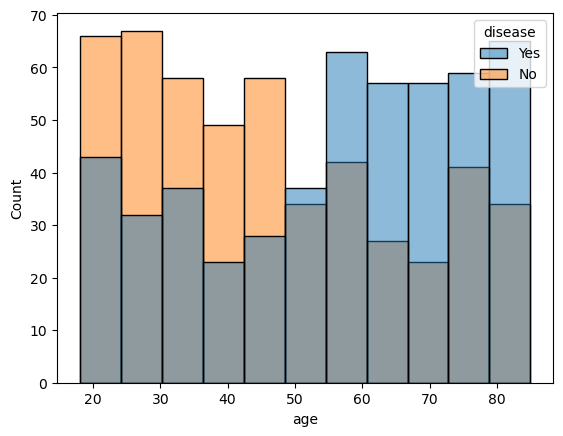

In [8]:
## Exploratory Data Analysis:

# Hist Plot:

sns.histplot(x='age',  hue='disease', data=df)
plt.show()

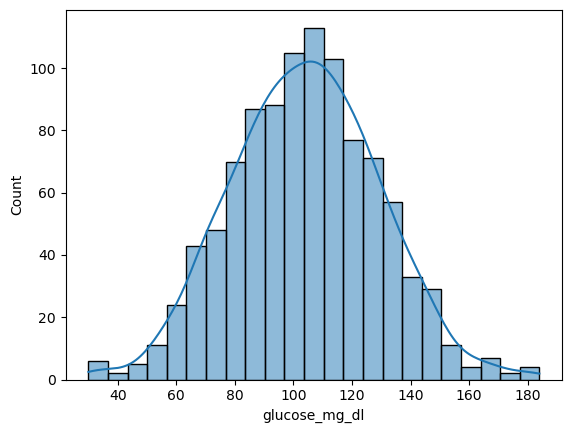

In [9]:
# Kde Plot:
# To check kernel density for glucose_mg_dl column:

sns.histplot(df['glucose_mg_dl'], kde=True)
plt.show()

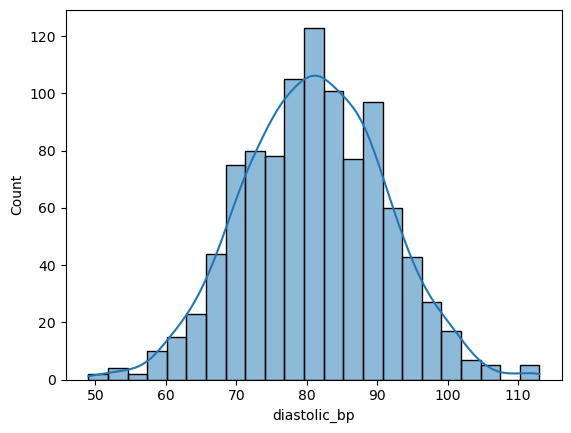

In [10]:
# To check kernel density for diastolic_bp column:

sns.histplot(df['diastolic_bp'], kde=True)
plt.show()

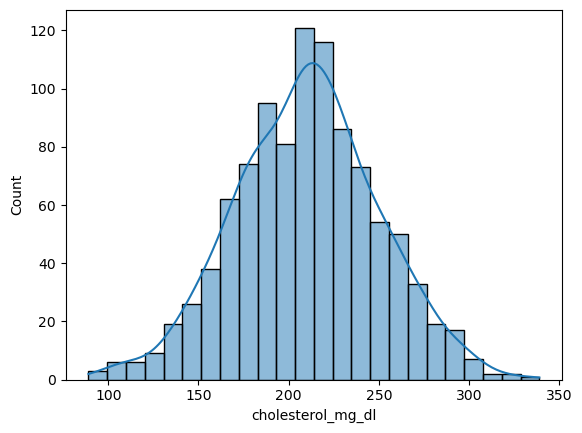

In [11]:
# To check kernel density for cholesterol_mg_dl column:

sns.histplot(df['cholesterol_mg_dl'], kde=True)
plt.show()

In [12]:
## Feature Scaling:

df.head()

,patient_id,age,gender,glucose_mg_dl,cholesterol_mg_dl,systolic_bp,diastolic_bp,bmi,heart_rate,smoking,alcohol_consumption,physical_activity,family_history,disease
0,1,32,Male,101,235,152,79,28.5,73,No,Yes,Low,Yes,Yes
1,2,31,Male,124,191,134,77,33.9,71,No,Yes,Low,Yes,Yes
2,3,45,Male,57,141,114,71,27.2,79,Yes,Yes,Low,No,No
3,4,75,Female,69,268,120,82,21.5,61,Yes,Yes,Medium,No,Yes
4,5,53,Male,107,163,131,75,23.3,73,Yes,No,Low,Yes,Yes


In [13]:
df.drop('patient_id',axis=1, inplace=True)

In [14]:
df.head()

,age,gender,glucose_mg_dl,cholesterol_mg_dl,systolic_bp,diastolic_bp,bmi,heart_rate,smoking,alcohol_consumption,physical_activity,family_history,disease
0,32,Male,101,235,152,79,28.5,73,No,Yes,Low,Yes,Yes
1,31,Male,124,191,134,77,33.9,71,No,Yes,Low,Yes,Yes
2,45,Male,57,141,114,71,27.2,79,Yes,Yes,Low,No,No
3,75,Female,69,268,120,82,21.5,61,Yes,Yes,Medium,No,Yes
4,53,Male,107,163,131,75,23.3,73,Yes,No,Low,Yes,Yes


In [15]:
## Categorical features:

cat_features = df.select_dtypes(include='object').columns
numeric_features = df.select_dtypes(exclude='object').columns
cat_features, numeric_features

(Index(['gender', 'smoking', 'alcohol_consumption', 'physical_activity',
        'family_history', 'disease'],
       dtype='object'),
 Index(['age', 'glucose_mg_dl', 'cholesterol_mg_dl', 'systolic_bp',
        'diastolic_bp', 'bmi', 'heart_rate'],
       dtype='object'))

In [16]:
df['glucose_category'] = df['glucose_mg_dl']
df['glucose_category'] = df['glucose_category'].apply(
    lambda x : 'Low' if x < 70 else('Medium' if x > 70 and x < 99 else 'High')
)

In [17]:
df['cholestrol_category'] = df['cholesterol_mg_dl']
df['cholestrol_category'] = df['cholestrol_category'].apply(
    lambda x : 'Low' if x < 150 else('Medium' if x < 200 else 'High')
)

In [18]:
df['systolic_bp_category'] = df['systolic_bp']
df['diastolic_bp_category'] = df['diastolic_bp']

df['systolic_bp_category'] = df['systolic_bp'].apply(
    lambda x : 'Low' if x < 90 else('Medium' if x > 90 and x < 130 else 'High')
)

df['diastolic_bp_category'] = df['diastolic_bp'].apply(
    lambda x : 'Low' if x < 60 else('Medium' if x > 60 and x < 89 else 'High')
)

In [19]:
df = df.replace({
    'Low' : 0,
    'Medium':1,
    'High': 2,
    'Male' : 0,
    'Female':1,
    'Yes' : 1,
    'No' : 0
})

C:\Users\siddhesh1606\AppData\Local\Temp\ipykernel_16072\1114141440.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace({


In [20]:
df.head()

,age,gender,glucose_mg_dl,cholesterol_mg_dl,systolic_bp,diastolic_bp,bmi,heart_rate,smoking,alcohol_consumption,physical_activity,family_history,disease,glucose_category,cholestrol_category,systolic_bp_category,diastolic_bp_category
0,32,0,101,235,152,79,28.5,73,0,1,0,1,1,2,2,2,1
1,31,0,124,191,134,77,33.9,71,0,1,0,1,1,2,1,2,1
2,45,0,57,141,114,71,27.2,79,1,1,0,0,0,0,0,1,1
3,75,1,69,268,120,82,21.5,61,1,1,1,0,1,0,2,1,1
4,53,0,107,163,131,75,23.3,73,1,0,0,1,1,2,1,2,1


In [21]:
df.rename(columns = {
    'smoking' : 'Is_Smoker',
    'gender' : 'Is_female'
},inplace = True)

In [22]:
df.head()

,age,Is_female,glucose_mg_dl,cholesterol_mg_dl,systolic_bp,diastolic_bp,bmi,heart_rate,Is_Smoker,alcohol_consumption,physical_activity,family_history,disease,glucose_category,cholestrol_category,systolic_bp_category,diastolic_bp_category
0,32,0,101,235,152,79,28.5,73,0,1,0,1,1,2,2,2,1
1,31,0,124,191,134,77,33.9,71,0,1,0,1,1,2,1,2,1
2,45,0,57,141,114,71,27.2,79,1,1,0,0,0,0,0,1,1
3,75,1,69,268,120,82,21.5,61,1,1,1,0,1,0,2,1,1
4,53,0,107,163,131,75,23.3,73,1,0,0,1,1,2,1,2,1


In [23]:
## Creating Training and Testing Data:
from sklearn.model_selection import train_test_split


X = df.drop(columns = ['disease'], axis=1)
y = df['disease']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [24]:
X_train.head()

,age,Is_female,glucose_mg_dl,cholesterol_mg_dl,systolic_bp,diastolic_bp,bmi,heart_rate,Is_Smoker,alcohol_consumption,physical_activity,family_history,glucose_category,cholestrol_category,systolic_bp_category,diastolic_bp_category
29,83,0,125,210,151,79,27.4,103,0,0,2,1,2,2,2,1
535,61,0,75,276,152,89,31.9,93,0,1,2,1,1,2,2,2
695,83,1,100,190,107,80,18.3,80,1,1,0,1,2,1,1,1
557,69,0,135,171,154,79,20.9,91,0,0,0,1,2,1,2,1
836,54,0,156,216,132,81,16.0,68,0,1,2,0,2,2,2,1


In [25]:
y_train.head()

29     0
535    1
695    1
557    1
836    0
Name: disease, dtype: int64

In [26]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
columns = ['age','glucose_mg_dl','cholesterol_mg_dl','systolic_bp','diastolic_bp','bmi','heart_rate','glucose_category','cholestrol_category','physical_activity']
X_train = scaler.fit_transform(X_train[columns])
X_test = scaler.fit_transform(X_test[columns])

In [27]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((800, 10), (200, 10), (800,), (200,))

In [28]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

LinearRegression()

In [29]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

y_pred = lin_reg.predict(X_test)

mae = mean_absolute_error(y_test , y_pred)
mse = mean_squared_error(y_test , y_pred)
rmse = np.sqrt(mse)

print(f'Mean Absolute Error: {mae}')
print(f'Mean Squared Error: {mse}')
print(f'Root Mean Squared Error: {rmse}')

Mean Absolute Error: 0.3446577271080462
Mean Squared Error: 0.15849160238067347
Root Mean Squared Error: 0.3981100380305343


### Model inference:

- The most revealing insight comes from comparing your MAE (0.34) and RMSE (0.40)
- Because your RMSE is only slightly higher than your MAE (0.40  vs  0.34), it infers that your model's errors are variance-stable.


## With Ordinary Least Square Method - Linear Regression

In [30]:
import statsmodels.api as sm

In [31]:
model = sm.OLS(y_train, X_train).fit()

In [32]:
prediction = model.predict(X_test)
print(prediction)

[ 9.08313659e-02 -2.90606101e-02 -3.31990437e-01 -1.02022726e-02
 -5.03616821e-01  1.03350739e-01  2.68384689e-01  6.54147296e-01
  1.38554710e-01  2.69348001e-01 -1.89286642e-01 -1.97773582e-02
 -5.92178600e-02 -4.11950199e-01  1.08311995e-03 -8.09095189e-02
 -3.13883587e-01 -2.58315514e-01  2.40608275e-01 -1.30767151e-02
 -9.57938710e-02 -6.11958608e-02  8.37681578e-02 -5.22674648e-01
 -6.81380859e-02  2.92900955e-01 -5.92590579e-02 -3.17050135e-01
 -2.19488108e-01 -2.38680913e-01 -3.82061423e-02  6.29456913e-02
 -3.32668059e-02 -1.89511837e-01  2.33065324e-01 -9.50175368e-03
  6.86266718e-02 -8.00668332e-01 -7.58902574e-02 -1.34199286e-01
 -1.93086469e-02  4.34211145e-01  4.54832074e-01  2.32441710e-01
 -2.26803926e-01 -3.96998877e-01  3.12741250e-01 -3.54566900e-01
  1.33253626e-01  1.30914670e-01 -1.84941501e-01 -1.36667073e-01
 -1.15915380e-01 -4.54384492e-01  7.42348654e-02  6.66412683e-02
 -3.65402247e-01 -3.25354250e-01  2.08222946e-01  8.84799646e-02
  1.16728272e-01 -3.54529

In [33]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:                disease   R-squared (uncentered):                   0.177
Model:                            OLS   Adj. R-squared (uncentered):              0.167
Method:                 Least Squares   F-statistic:                              16.98
Date:                Wed, 17 Jun 2026   Prob (F-statistic):                    4.22e-28
Time:                        09:58:38   Log-Likelihood:                         -785.96
No. Observations:                 800   AIC:                                      1592.
Df Residuals:                     790   BIC:                                      1639.
Df Model:                          10                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------